PyTorch: 2.11.0+cu128
Device: cuda
Target digit: {8, 4}
Used images: 6000
Number of parameters: 263553
Epoch 1/100 loss=0.7615
Epoch 2/100 loss=0.2857
Epoch 3/100 loss=0.2624
Epoch 4/100 loss=0.2574
Epoch 5/100 loss=0.2453
Epoch 6/100 loss=0.2329
Epoch 7/100 loss=0.2154
Epoch 8/100 loss=0.2052
Epoch 9/100 loss=0.1946
Epoch 10/100 loss=0.1831
Epoch 11/100 loss=0.1752
Epoch 12/100 loss=0.1561
Epoch 13/100 loss=0.1531
Epoch 14/100 loss=0.1485
Epoch 15/100 loss=0.1384
Epoch 16/100 loss=0.1411
Epoch 17/100 loss=0.1322
Epoch 18/100 loss=0.1269
Epoch 19/100 loss=0.1226
Epoch 20/100 loss=0.1172
Epoch 21/100 loss=0.1210
Epoch 22/100 loss=0.1127
Epoch 23/100 loss=0.1112
Epoch 24/100 loss=0.1094
Epoch 25/100 loss=0.1064
Epoch 26/100 loss=0.1063
Epoch 27/100 loss=0.1089
Epoch 28/100 loss=0.1035
Epoch 29/100 loss=0.0997
Epoch 30/100 loss=0.1007
Epoch 31/100 loss=0.0986
Epoch 32/100 loss=0.0968
Epoch 33/100 loss=0.0950
Epoch 34/100 loss=0.1010
Epoch 35/100 loss=0.0952
Epoch 36/100 loss=0.0952
Epoch 

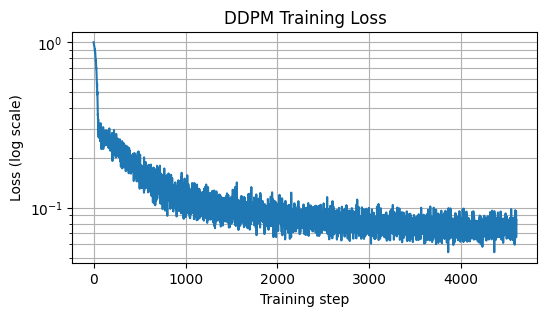

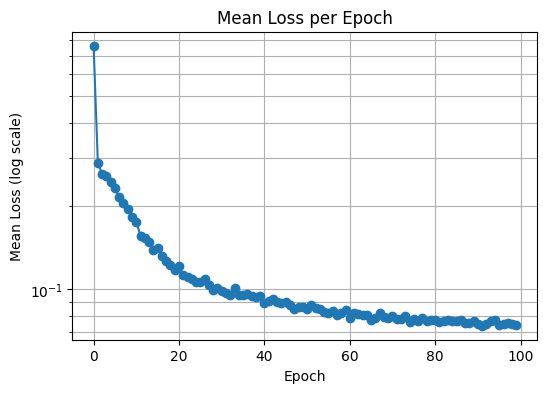

In [8]:
# -*- coding: utf-8 -*-
# ============================================
# MNIST Unconditional Image DDPM
# Simple time-dependent Conv U-Net
# ResBlockなし版
# input/output: 32x32 grayscale
# ============================================

import os
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import MNIST

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device:", device)

# ============================================
# MNIST Dataset
# ============================================

IMG_SIZE = 32 #半々にスケール変換したいので、リサイズする
BATCH = 128

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),  # [0,1] -> [-1,1]
])

mnist_train_full = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tf,
)

TARGET_DIGITS = {4, 8}
MAX_IMAGES_PER_DIGIT = 3000

counts = {d: 0 for d in TARGET_DIGITS}
indices = []

for i, (_, y) in enumerate(mnist_train_full):
    if y in TARGET_DIGITS and counts[y] < MAX_IMAGES_PER_DIGIT:
        indices.append(i)
        counts[y] += 1

dataset = Subset(mnist_train_full, indices)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print("Target digit:", TARGET_DIGITS)
print("Used images:", len(dataset))



class SimpleUNet2D(nn.Module):
    def __init__(self, img_ch=1, base_ch=64):
        super().__init__()

        self.in_conv = nn.Conv2d(img_ch, base_ch, kernel_size=3, padding=1)

        self.down_conv = nn.Conv2d(
            base_ch, base_ch * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_conv = nn.ConvTranspose2d(
            base_ch * 2, base_ch,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.out_conv = nn.Conv2d(base_ch, img_ch, kernel_size=3, padding=1)

        self.act = nn.SiLU()

    def forward(self, x):
        x0 = self.in_conv(x)

        x1 = self.down_conv(x0)
        x1 = self.act(x1)

        u2 = self.up_conv(x1)
        u2 = self.act(u2)

        return self.out_conv(u2)


# ============================================
# DDPM
# ============================================

def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    x = np.linspace(0, T, steps)

    alphas_cum = np.cos(((x / T) + s) / (1 + s) * np.pi / 2) ** 2
    alphas_cum = alphas_cum / alphas_cum[0]

    betas = 1 - (alphas_cum[1:] / alphas_cum[:-1])
    return np.clip(betas, 1e-5, 0.999)


class DDPM:
    def __init__(self, T=500):
        self.T = T

        betas = cosine_beta_schedule(T)
        alphas = 1.0 - betas
        alphas_cum = np.cumprod(alphas)
        alphas_cum_prev = np.concatenate([[1.0], alphas_cum[:-1]])

        self.betas = torch.tensor(betas, dtype=torch.float32, device=device)
        self.alphas = torch.tensor(alphas, dtype=torch.float32, device=device)
        self.a_bar = torch.tensor(alphas_cum, dtype=torch.float32, device=device)
        self.a_bar_prev = torch.tensor(alphas_cum_prev, dtype=torch.float32, device=device)

    def q_sample(self, x0, t):
        """
        forward diffusion:
        x_t = sqrt(a_bar_t) x0 + sqrt(1-a_bar_t) eps
        """
        noise = torch.randn_like(x0)

        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)

        x_t = torch.sqrt(a_bar_t) * x0 + torch.sqrt(1 - a_bar_t) * noise

        return x_t, noise


ddpm = DDPM(T=500)


# ============================================
# Model, EMA, optimizer
# ============================================

def update_ema(model, ema_model, decay=0.999):
    with torch.no_grad():
        for p, ep in zip(model.parameters(), ema_model.parameters()):
            ep.data.mul_(decay).add_(p.data * (1 - decay))


unet = SimpleUNet2D(img_ch=1, base_ch=64).to(device)
ema_unet = copy.deepcopy(unet).to(device)

optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Number of parameters:", sum(p.numel() for p in unet.parameters()))


# ============================================
# Training step
# ============================================

def train_step(batch):
    unet.train()

    x0, _ = batch
    x0 = x0.to(device)

    B = x0.shape[0]

    t = torch.randint(
        low=0,
        high=ddpm.T,
        size=(B,),
        device=device
    )

    x_noisy, eps_true = ddpm.q_sample(x0, t)
    eps_pred = unet(x_noisy)

    loss = F.mse_loss(eps_pred, eps_true)

    optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)

    optimizer.step()

    update_ema(unet, ema_unet, decay=0.999)

    return loss.item()


# ============================================
# Training loop
# ============================================

############
EPOCHS = 100
############

loss_history = []
epoch_loss_history = []

for ep in range(EPOCHS):
    losses = []

    for batch in train_loader:
        loss = train_step(batch)
        losses.append(loss)
        loss_history.append(loss)

    epoch_loss = float(np.mean(losses))
    epoch_loss_history.append(epoch_loss)

    print(f"Epoch {ep+1}/{EPOCHS} loss={epoch_loss:.4f}")


# minibatchごとのloss
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Loss (log scale)")
plt.title("DDPM Training Loss")
plt.grid(True, which="both")
plt.show()


# epochごとの平均loss
plt.figure(figsize=(6, 4))
plt.plot(epoch_loss_history, marker="o")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Mean Loss (log scale)")
plt.title("Mean Loss per Epoch")
plt.grid(True, which="both")
plt.show()

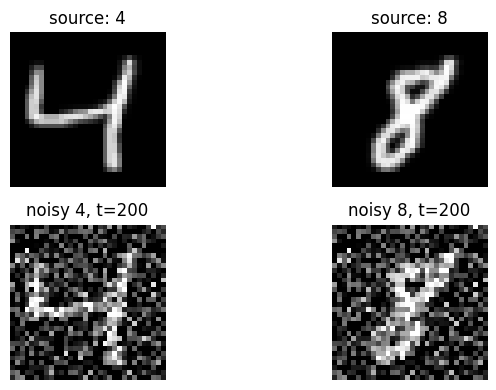

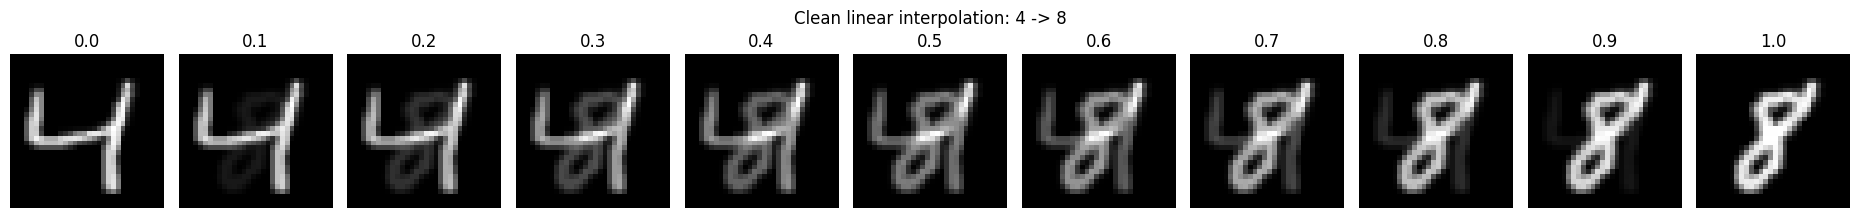

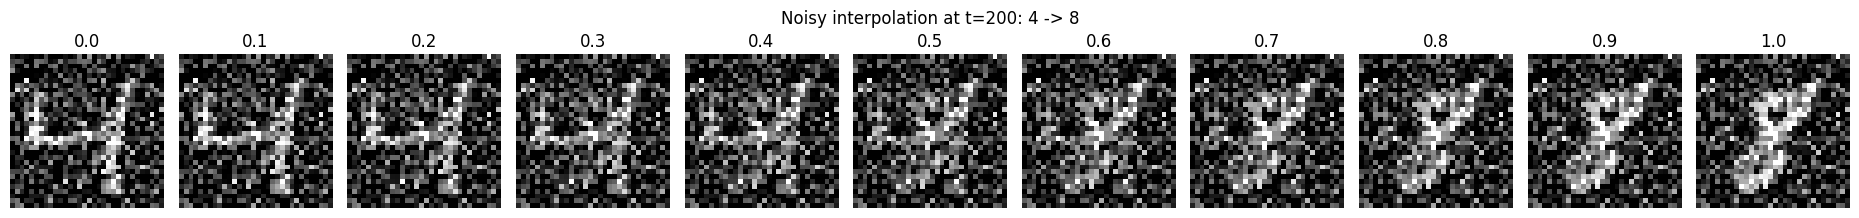

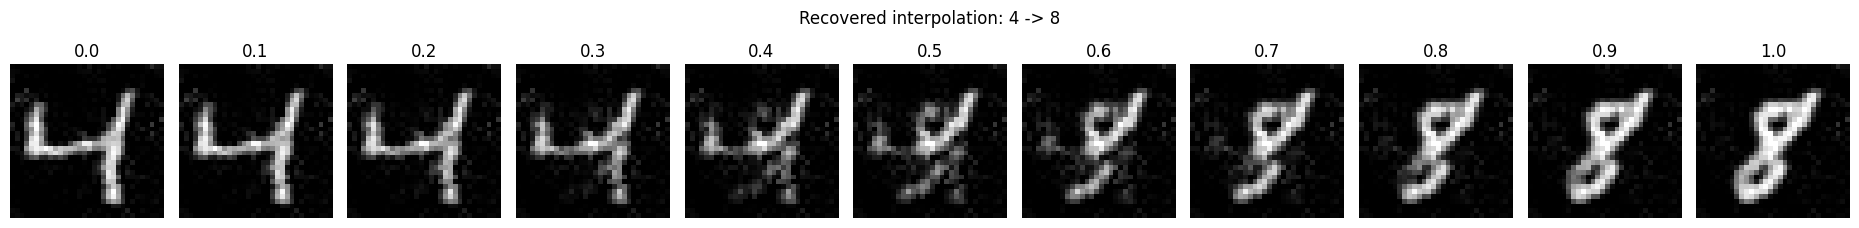

In [9]:
# ============================================
# Continuous interpolation experiment
# 例: 4 -> 9, または 1 -> 7
# ============================================

@torch.no_grad()
def q_sample_with_given_noise(x0, t, noise):
    """
    指定した noise を使って forward diffusion する。
    2枚の画像に同じ noise を使うために用意する。
    """
    a_bar_t = ddpm.a_bar[t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(a_bar_t) * x0 + torch.sqrt(1.0 - a_bar_t) * noise
    return x_t


def get_nth_example_of_digit(subset_dataset, digit, n=0):
    """
    dataset から指定 digit の n 番目の画像を取り出す。
    """
    count = 0

    for i in range(len(subset_dataset)):
        x, y = subset_dataset[i]

        if y == digit:
            if count == n:
                return x, y
            count += 1

    raise ValueError(f"Digit {digit} not found enough times.")

@torch.no_grad()
def reverse_from_xt_deterministic(x, t_start):
    """
    DDIM deterministic sampler, eta=0.
    x_{t_start} から x_0 まで、ノイズを足さずに戻す。

    DDPM mean ではなく、
        x_t = sqrt(a_bar_t) x0 + sqrt(1-a_bar_t) eps
    という分解を使って、
        a_bar_t -> a_bar_{t-1}
    へ係数を付け替える。
    """
    ema_unet.eval()

    x = x.clone().to(device)

    for t in reversed(range(t_start + 1)):
        t_vec = torch.full(
            (x.shape[0],),
            t,
            device=device,
            dtype=torch.long
        )

        # 通常のDDPM/DDIMでは eps_theta(x_t, t) を予測する
        # あなたのモデルが t を受け取るなら ema_unet(x, t_vec)
        # 受け取らない実装なら ema_unet(x) にする
        try:
            eps = ema_unet(x, t_vec)
        except TypeError:
            eps = ema_unet(x)

        a_bar_t = ddpm.a_bar[t]

        # 1. x0 prediction
        x0_hat = (
            x - torch.sqrt(1.0 - a_bar_t) * eps
        ) / torch.sqrt(a_bar_t)

        # t=0 なら x0_hat が最終出力
        if t == 0:
            x = x0_hat
        else:
            a_bar_prev = ddpm.a_bar[t - 1]

            # 2. deterministic DDIM update
            x = (
                torch.sqrt(a_bar_prev) * x0_hat
                +
                torch.sqrt(1.0 - a_bar_prev) * eps
            )

    x = torch.clamp(x, -1, 1)
    return x.cpu()

@torch.no_grad()
def interpolate_between_digits(
    digit_a=None,
    digit_b=None,
    t_star=300,
    num_points=11,
    idx_a=0,
    idx_b=0,
    use_same_noise=True
):
    """
    digit_a の画像と digit_b の画像を同じ時刻 t_star までノイズ化し、
    その noisy image 空間で線形補間してから決定論的 reverse で戻す。

    さらに、比較用として、
    ノイズを入れていない元画像空間での線形補間 xlin_list も作る。
    """

    if digit_a is None or digit_b is None:
        ds = sorted(list(TARGET_DIGITS))
        digit_a, digit_b = ds[0], ds[1]

    x_a, _ = get_nth_example_of_digit(dataset, digit_a, n=idx_a)
    x_b, _ = get_nth_example_of_digit(dataset, digit_b, n=idx_b)

    x_a = x_a.unsqueeze(0).to(device)
    x_b = x_b.unsqueeze(0).to(device)

    t_tensor = torch.tensor([t_star], device=device, dtype=torch.long)

    noise_a = torch.randn_like(x_a)

    if use_same_noise:
        noise_b = noise_a.clone()
    else:
        noise_b = torch.randn_like(x_b)

    xt_a = q_sample_with_given_noise(x_a, t_tensor, noise_a)
    xt_b = q_sample_with_given_noise(x_b, t_tensor, noise_b)

    lams = torch.linspace(0.0, 1.0, num_points, device=device)

    xlin_list = []
    xt_list = []
    xrec_list = []

    for lam in lams:
        # --------------------------------------------
        # 1. ノイズなしの画像空間での線形補間
        # --------------------------------------------
        xlin = (1.0 - lam) * x_a + lam * x_b

        # --------------------------------------------
        # 2. noisy image 空間での線形補間
        # --------------------------------------------
        xt = (1.0 - lam) * xt_a + lam * xt_b

        # --------------------------------------------
        # 3. noisy interpolation を reverse diffusion で戻す
        # --------------------------------------------
        xrec = reverse_from_xt_deterministic(xt, t_star)

        xlin_list.append(xlin.cpu()[0])
        xt_list.append(xt.cpu()[0])
        xrec_list.append(xrec[0])

    xlin_list = torch.stack(xlin_list)
    xt_list = torch.stack(xt_list)
    xrec_list = torch.stack(xrec_list)

    return {
        "digit_a": digit_a,
        "digit_b": digit_b,
        "x_a": x_a.cpu()[0],
        "x_b": x_b.cpu()[0],
        "xt_a": xt_a.cpu()[0],
        "xt_b": xt_b.cpu()[0],
        "xlin_list": xlin_list,
        "xt_list": xt_list,
        "xrec_list": xrec_list,
        "lams": lams.cpu(),
        "t_star": t_star,
    }


def show_interpolation_result(result):
    digit_a = result["digit_a"]
    digit_b = result["digit_b"]
    x_a = result["x_a"]
    x_b = result["x_b"]
    xt_a = result["xt_a"]
    xt_b = result["xt_b"]
    xlin_list = result["xlin_list"]
    xt_list = result["xt_list"]
    xrec_list = result["xrec_list"]
    lams = result["lams"]
    t_star = result["t_star"]

    # ============================================
    # endpoint images
    # ============================================
    plt.figure(figsize=(8, 4))

    plt.subplot(2, 2, 1)
    plt.imshow(((x_a + 1) / 2).clamp(0, 1)[0], cmap="gray")
    plt.title(f"source: {digit_a}")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(((x_b + 1) / 2).clamp(0, 1)[0], cmap="gray")
    plt.title(f"source: {digit_b}")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(((xt_a + 1) / 2).clamp(0, 1)[0], cmap="gray")
    plt.title(f"noisy {digit_a}, t={t_star}")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(((xt_b + 1) / 2).clamp(0, 1)[0], cmap="gray")
    plt.title(f"noisy {digit_b}, t={t_star}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ============================================
    # clean interpolation without noise
    # ============================================
    num_points = len(lams)
    xlin_show = ((xlin_list + 1) / 2).clamp(0, 1)

    plt.figure(figsize=(1.7 * num_points, 2.2))

    for i in range(num_points):
        plt.subplot(1, num_points, i + 1)
        plt.imshow(xlin_show[i, 0], cmap="gray")
        plt.title(f"{lams[i].item():.1f}")
        plt.axis("off")

    plt.suptitle(f"Clean linear interpolation: {digit_a} -> {digit_b}")
    plt.tight_layout()
    plt.show()

    # ============================================
    # noisy interpolation
    # ============================================
    xt_show = ((xt_list + 1) / 2).clamp(0, 1)

    plt.figure(figsize=(1.7 * num_points, 2.2))

    for i in range(num_points):
        plt.subplot(1, num_points, i + 1)
        plt.imshow(xt_show[i, 0], cmap="gray")
        plt.title(f"{lams[i].item():.1f}")
        plt.axis("off")

    plt.suptitle(f"Noisy interpolation at t={t_star}: {digit_a} -> {digit_b}")
    plt.tight_layout()
    plt.show()

    # ============================================
    # recovered interpolation
    # ============================================
    xrec_show = ((xrec_list + 1) / 2).clamp(0, 1)

    plt.figure(figsize=(1.7 * num_points, 2.4))

    for i in range(num_points):
        plt.subplot(1, num_points, i + 1)
        plt.imshow(xrec_show[i, 0], cmap="gray")
        plt.title(f"{lams[i].item():.1f}")
        plt.axis("off")

    plt.suptitle(f"Recovered interpolation: {digit_a} -> {digit_b}")
    plt.tight_layout()
    plt.show()


# ============================================
# Run interpolation
# ============================================

result = interpolate_between_digits(
    digit_a=None,
    digit_b=None,
    t_star=200,
    num_points=11,
    idx_a=0,
    idx_b=0,
    use_same_noise=True
)

show_interpolation_result(result)